In [19]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")

In [20]:
# LOAD DATASET
df_diabetes = pd.read_csv("diabetes.csv")

# Clean column names
df_diabetes.columns = df_diabetes.columns.str.strip().str.lower()

df_diabetes.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
# DATA UNDERSTANDING

print("Shape:", df_diabetes.shape)

Shape: (768, 9)


In [22]:
print("\nInfo:")
print(df_diabetes.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   768 non-null    int64  
 2   bloodpressure             768 non-null    int64  
 3   skinthickness             768 non-null    int64  
 4   insulin                   768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [23]:
print("\nMissing Values:")
print(df_diabetes.isnull().sum())


Missing Values:
pregnancies                 0
glucose                     0
bloodpressure               0
skinthickness               0
insulin                     0
bmi                         0
diabetespedigreefunction    0
age                         0
outcome                     0
dtype: int64


In [24]:
print("\nStatistical Summary:")
print(df_diabetes.describe())


Statistical Summary:
       pregnancies     glucose  bloodpressure  skinthickness     insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              bmi  diabetespedigreefunction         age     outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.00

In [25]:
# DATA CLEANING

# Replace invalid zeros with NaN
cols = ["glucose", "bloodpressure", "skinthickness", "insulin", "bmi"]

for col in cols:
    df_diabetes[col] = df_diabetes[col].replace(0, np.nan)

# Fill missing values with median
df_diabetes.fillna(df_diabetes.median(), inplace=True)

# Remove duplicates
df_diabetes = df_diabetes.drop_duplicates()


print("After cleaning:", df_diabetes.shape)

After cleaning: (768, 9)


In [26]:
# DATA PREPARATION

X = df_diabetes.drop("outcome", axis=1)
y = df_diabetes["outcome"]

print("Before SMOTE:", y.value_counts().to_dict())

# Apply SMOTE first (before scaling)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

# Then scale the resampled data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

Before SMOTE: {0: 500, 1: 268}
After SMOTE: {1: 500, 0: 500}


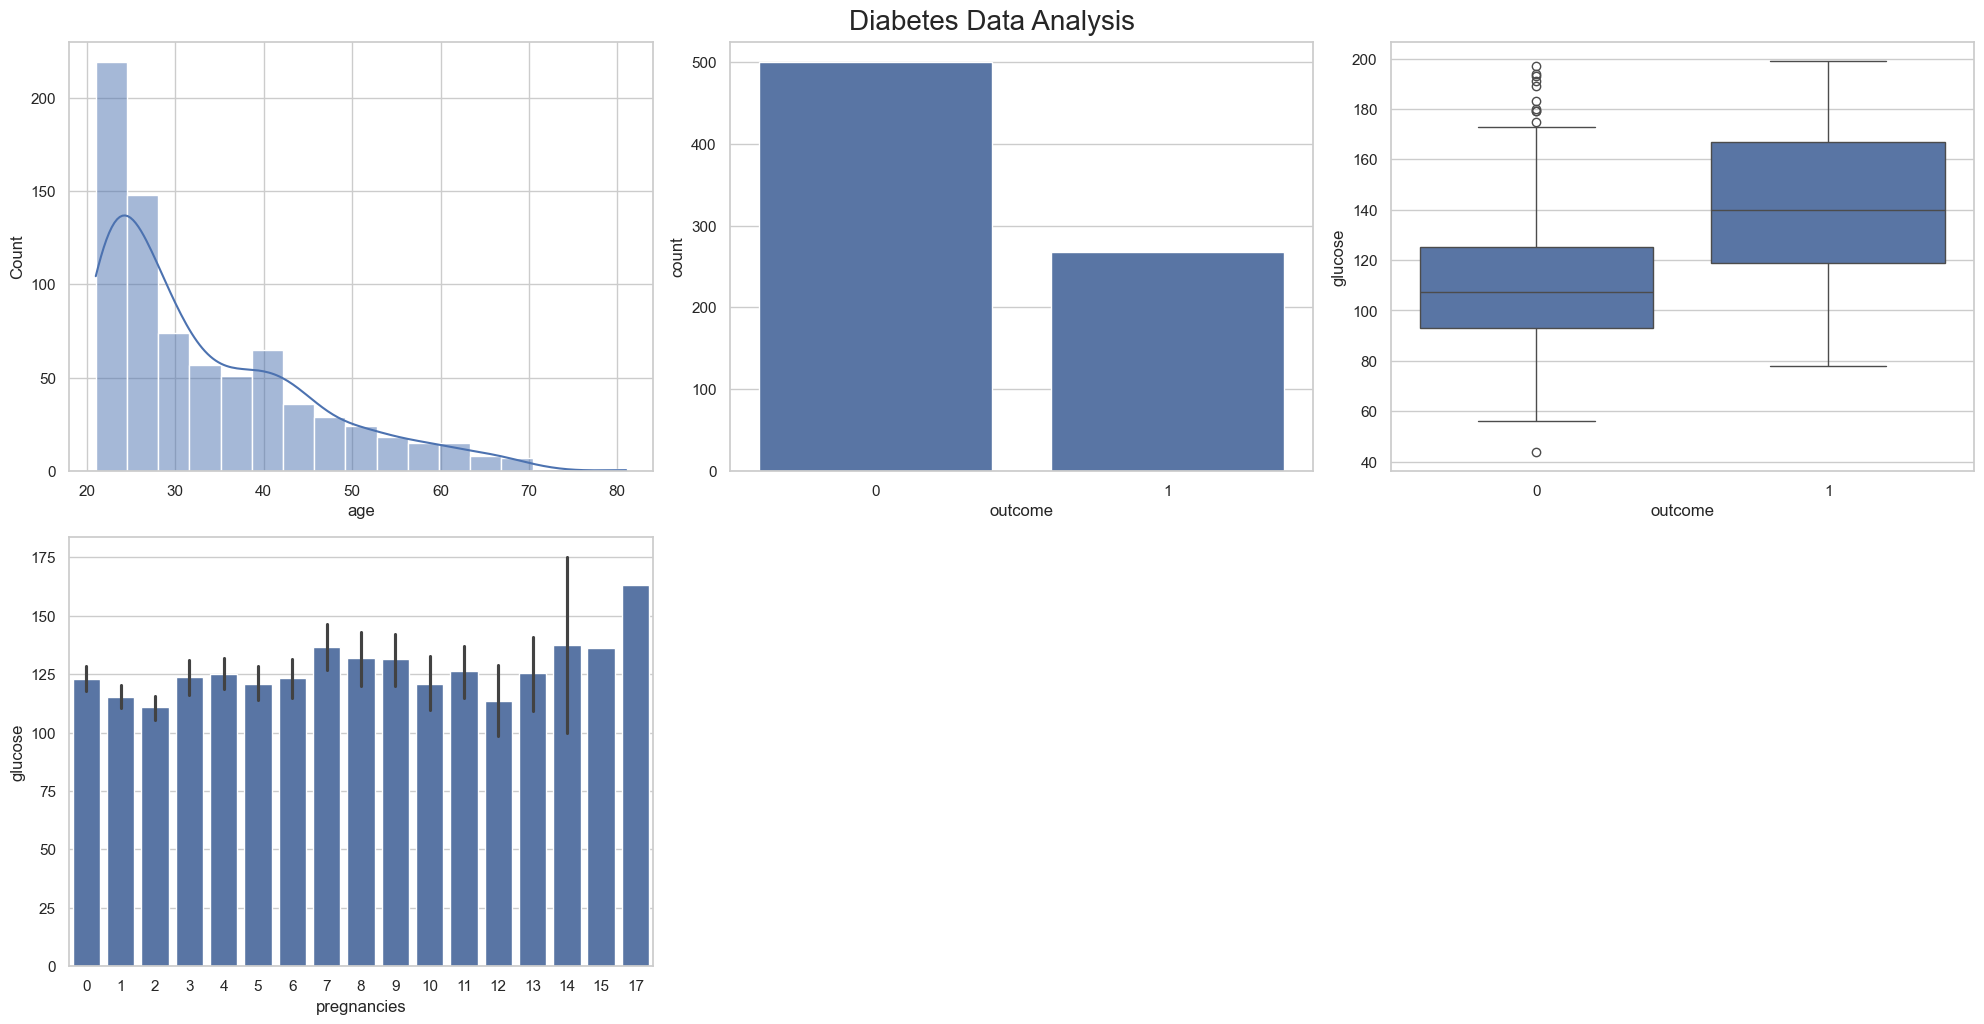

In [27]:
# VISUALIZATION

plt.figure(figsize=(20, 15))
plt.suptitle("Diabetes Data Analysis", fontsize=20)

# 1. Histogram
plt.subplot(3, 3, 1)
sns.histplot(df_diabetes["age"], kde=True)

# 2. Countplot
plt.subplot(3, 3, 2)
sns.countplot(x="outcome", data=df_diabetes)

# 3. Boxplot
plt.subplot(3, 3, 3)
sns.boxplot(x="outcome", y="glucose", data=df_diabetes)

# 4. Barplot
plt.subplot(3, 3, 4)
sns.barplot(x="pregnancies", y="glucose", data=df_diabetes)

plt.tight_layout()
plt.show()

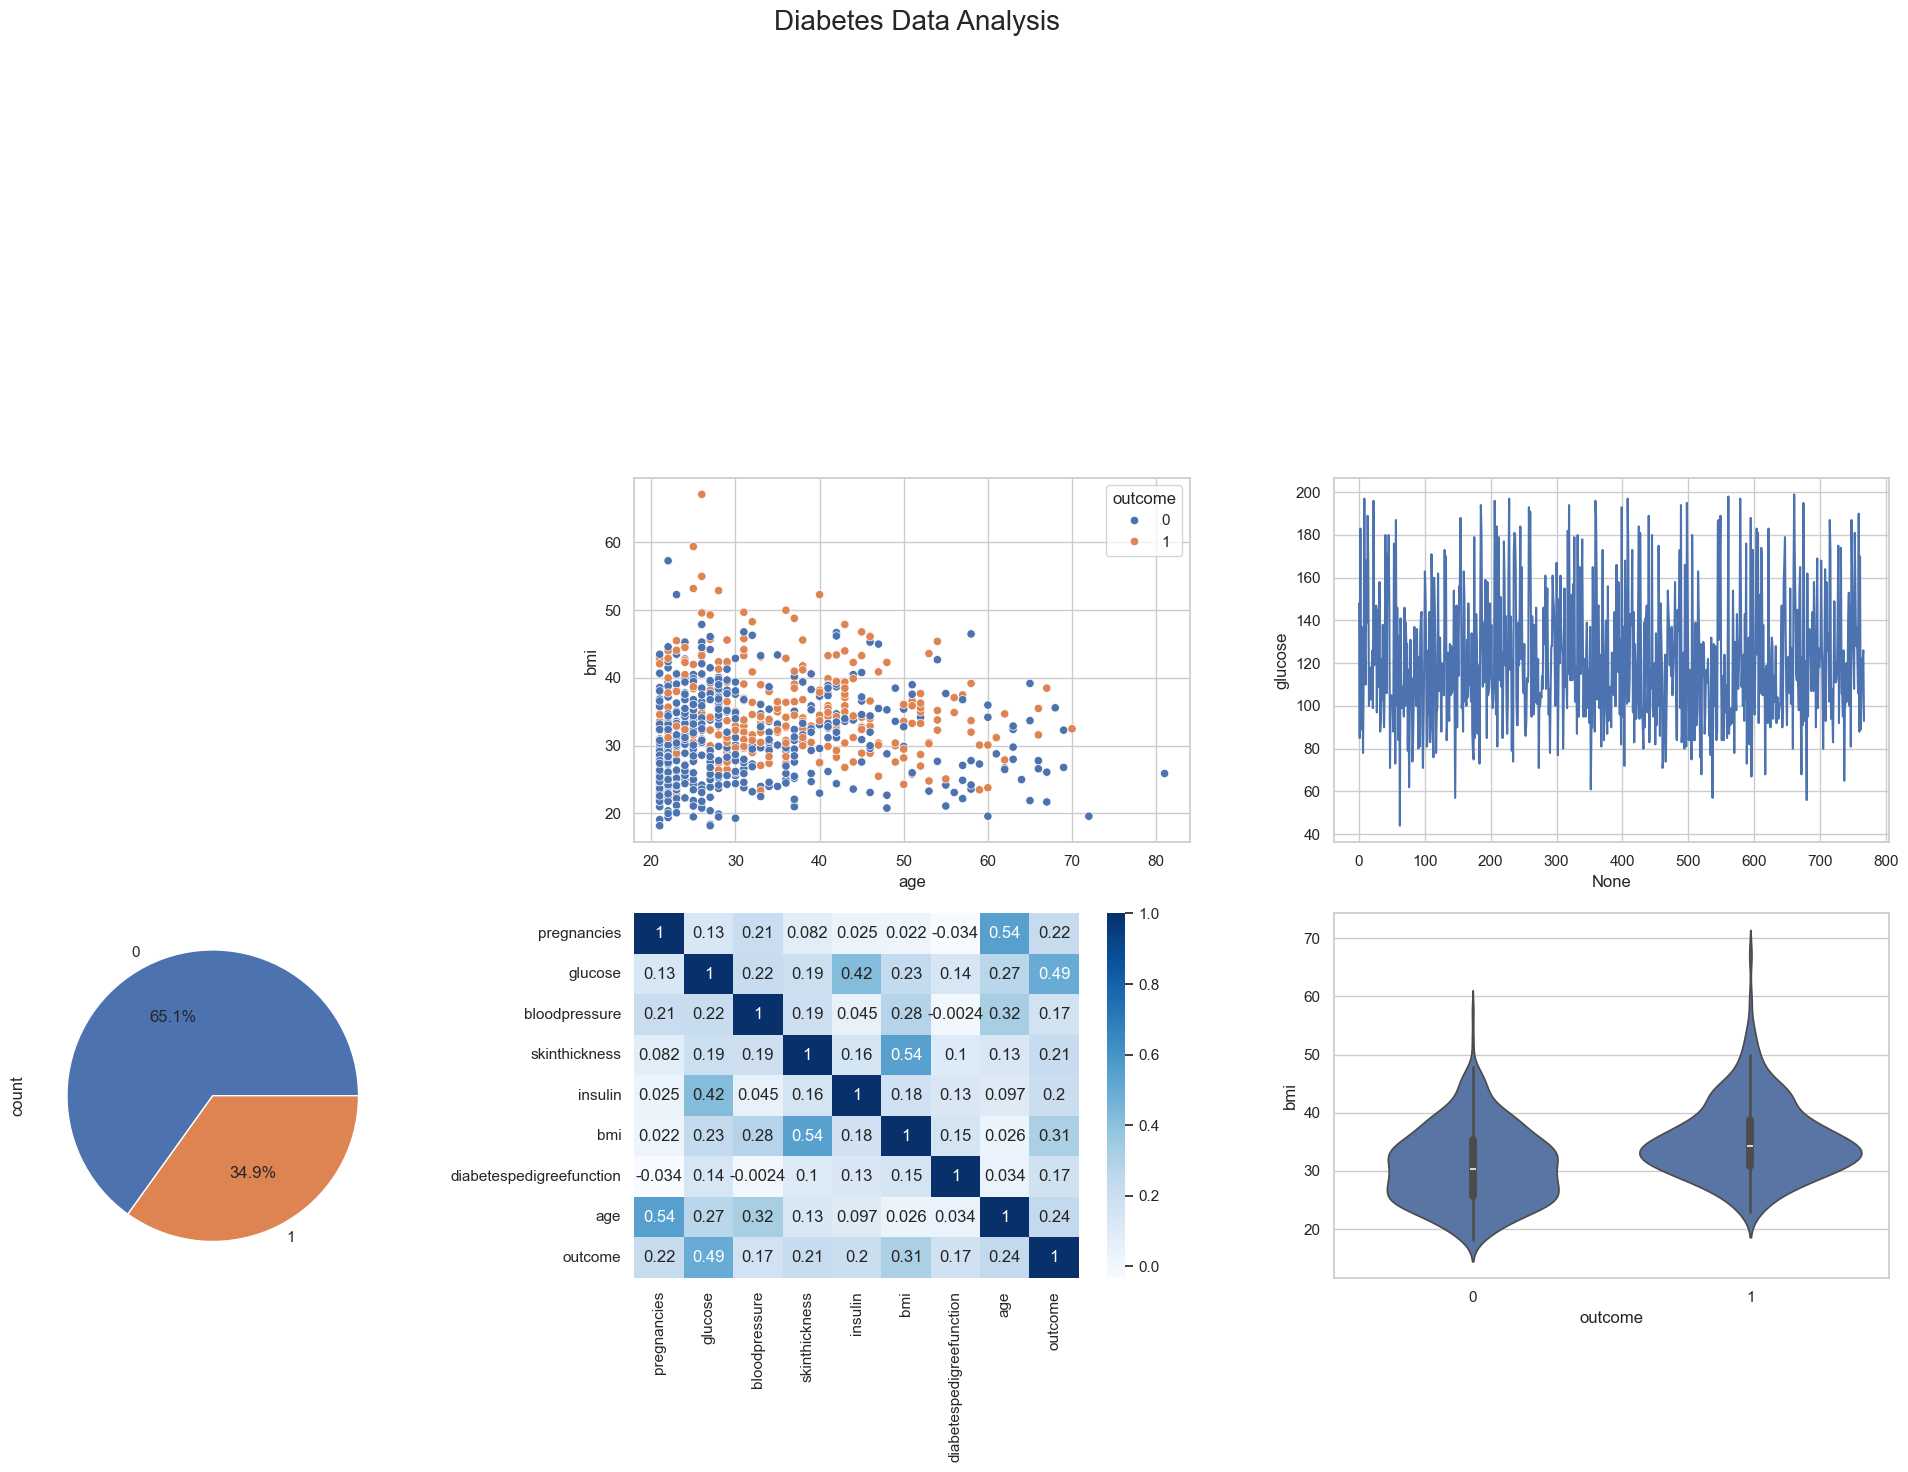

In [28]:
plt.figure(figsize=(20, 15))
plt.suptitle("Diabetes Data Analysis", fontsize=20)

# 5. Scatterplot
plt.subplot(3, 3, 5)
sns.scatterplot(x="age", y="bmi", hue="outcome", data=df_diabetes)

# 6. Lineplot
plt.subplot(3, 3, 6)
sns.lineplot(x=df_diabetes.index, y="glucose", data=df_diabetes)

# 7. Pie Chart
plt.subplot(3, 3, 7)
df_diabetes["outcome"].value_counts().plot.pie(autopct="%1.1f%%")

# 8. Heatmap
plt.subplot(3, 3, 8)
sns.heatmap(df_diabetes.corr(), annot=True, cmap="Blues")

# 9. Violin Plot
plt.subplot(3, 3, 9)
sns.violinplot(x="outcome", y="bmi", data=df_diabetes)

plt.tight_layout()
plt.show()

In [ ]:
# EXTRA VISUALIZATION - PAIRPLOT

sns.pairplot(df_diabetes, hue="outcome")
plt.suptitle("Pairplot of Diabetes Dataset", y=1.02)
plt.show()

In [ ]:
# MACHINE LEARNING - LOGISTIC REGRESSION

# SMOTE wale resampled data se features select karo
X_resampled_df = pd.DataFrame(
    X_resampled, columns=df_diabetes.drop("outcome", axis=1).columns
)

# Strong features
feature_cols = ["glucose", "bmi", "age", "insulin"]
X_final = X_resampled_df[feature_cols]
y_final = pd.Series(y_resampled)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "diabetes_scaler.pkl")

# Logistic Regression
lr_diabetes = LogisticRegression(max_iter=3000)
lr_diabetes.fit(X_train, y_train)

y_pred_lr = lr_diabetes.predict(X_test)

joblib.dump(lr_diabetes, "diabetes_model.pkl")

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

In [ ]:
# MACHINE LEARNING - RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=4,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features=2,
    random_state=36,
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, pred_rf))

In [ ]:
# MODEL EVALUATION

print(classification_report(y_test, y_pred_lr))

In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Diabetes Model")
plt.show()

In [ ]:
joblib.dump(rf, "diabetes_rf_model.pkl")
print("RF Model saved!")